# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZubairQazzi/flyrank-ml-internship-zubair/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can historical search-performance signals help prioritize which published content pages should receive human review for possible refresh work?

The unit of analysis is a published content page. The output is a model score and ranked queue that helps an editor decide which pages to inspect first.

The intended use is decision support. A high score does not mean a page must be refreshed, and it does not prove that refreshing the page will improve future search performance.

The practical goal is to reduce the amount of manual review needed across a large content portfolio while keeping the final content decision with a human reviewer.

A wrong high-priority recommendation can waste editorial effort or encourage an unnecessary change. A wrong low-priority recommendation can delay review of a page that may deserve attention.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data used

This project uses the FlyRank ML Internship dataset, which contains pseudonymized production search-performance data.

For the final analysis, I use:

- daily content performance data from `fact_content_daily_performance`
- content metadata from `dim_content`

The feature window is March 1–21, 2026. The later March 22–31, 2026 window is used only to define the evaluation outcome.

The final evaluation population includes published, non-deleted pages with:

- at least 7 observed GSC days in the feature window
- at least 5 observed GSC days in the outcome window
- at least 100 historical impressions

The five model features are:

- `past_impressions`
- `past_clicks`
- `past_ctr`
- `past_avg_position`
- `gsc_observed_days`

Pseudonymous client and content IDs are used only for grouping, joins, and evaluation. They are not model features.                             
Label-derived fields such as `trend_direction` and `trend_pct`, future-window information, client names, page URLs, and private query data are deliberately excluded.

The warehouse release used for this project is build `20260703`.

In [7]:
from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np

# --------------------------------------------------
# Setup
# --------------------------------------------------

hf_token = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(
    f"""
    CREATE SECRET hf_secret (
        TYPE huggingface,
        TOKEN '{hf_token}'
    )
    """
)

march_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-03/*.parquet"
)

content_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "dim_content.parquet"
)

# --------------------------------------------------
# Build the same feature/outcome frame used earlier
# --------------------------------------------------

capstone_query = f"""
WITH daily_windows AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-21'
                 AND gsc_data_available IS TRUE
                THEN gsc_impressions
                ELSE 0
            END
        ) AS past_impressions,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-21'
                 AND gsc_data_available IS TRUE
                THEN gsc_clicks
                ELSE 0
            END
        ) AS past_clicks,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-21'
                 AND gsc_data_available IS TRUE
                THEN gsc_sum_position
                ELSE 0
            END
        ) AS past_sum_position,

        COUNT(*) FILTER (
            WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-21'
              AND gsc_data_available IS TRUE
        ) AS gsc_observed_days,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-03-22' AND DATE '2026-03-31'
                 AND gsc_data_available IS TRUE
                THEN gsc_impressions
                ELSE 0
            END
        ) AS outcome_impressions,

        COUNT(*) FILTER (
            WHERE report_date BETWEEN DATE '2026-03-22' AND DATE '2026-03-31'
              AND gsc_data_available IS TRUE
        ) AS outcome_days

    FROM read_parquet('{march_path}')
    GROUP BY client_hash_id, content_hash_id
),

content_dates AS (
    SELECT
        client_hash_id,
        content_hash_id,
        is_published,
        is_deleted,

        NULLIF(
            GREATEST(
                COALESCE(
                    CASE
                        WHEN last_optimized_date <= DATE '2026-03-21'
                        THEN last_optimized_date
                    END,
                    DATE '1900-01-01'
                ),
                COALESCE(
                    CASE
                        WHEN content_updated_date <= DATE '2026-03-21'
                        THEN content_updated_date
                    END,
                    DATE '1900-01-01'
                ),
                COALESCE(
                    CASE
                        WHEN content_created_date <= DATE '2026-03-21'
                        THEN content_created_date
                    END,
                    DATE '1900-01-01'
                )
            ),
            DATE '1900-01-01'
        ) AS last_known_update_date

    FROM read_parquet('{content_path}')
)

SELECT
    d.client_hash_id,
    d.content_hash_id,
    d.past_impressions,
    d.past_clicks,

    ROUND(
        100.0 * d.past_clicks /
        NULLIF(d.past_impressions, 0),
        4
    ) AS past_ctr,

    ROUND(
        1.0 * d.past_sum_position /
        NULLIF(d.past_impressions, 0),
        4
    ) AS past_avg_position,

    d.gsc_observed_days,

    DATE_DIFF(
        'day',
        c.last_known_update_date,
        DATE '2026-03-21'
    ) AS days_since_update,

    CASE
        WHEN
            (1.0 * d.outcome_impressions / d.outcome_days)
            <
            0.80 * (
                1.0 * d.past_impressions /
                d.gsc_observed_days
            )
        THEN 1
        ELSE 0
    END AS future_decline

FROM daily_windows d

INNER JOIN content_dates c
    ON d.client_hash_id = c.client_hash_id
   AND d.content_hash_id = c.content_hash_id

WHERE
    c.is_published IS TRUE
    AND COALESCE(c.is_deleted, FALSE) IS FALSE
    AND d.gsc_observed_days >= 7
    AND d.outcome_days >= 5
    AND d.past_impressions >= 100
"""

capstone_frame = con.sql(capstone_query).df()

# Deterministic row order for reproducible splitting
capstone_frame = (
    capstone_frame
    .sort_values(["client_hash_id", "content_hash_id"])
    .reset_index(drop=True)
)

print("Capstone rows:", len(capstone_frame))
print("Unique clients:", capstone_frame["client_hash_id"].nunique())
print(
    "Positive base rate:",
    round(capstone_frame["future_decline"].mean(), 4)
)

capstone_frame[
    [
        "past_impressions",
        "past_clicks",
        "past_ctr",
        "past_avg_position",
        "gsc_observed_days",
        "days_since_update",
        "future_decline",
    ]
].head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Capstone rows: 85967
Unique clients: 39
Positive base rate: 0.3249


,past_impressions,past_clicks,past_ctr,past_avg_position,gsc_observed_days,days_since_update,future_decline
0,190.0,1.0,0.5263,12.2316,21,24,0
1,353.0,0.0,0.0000,13.4051,21,165,1
2,106.0,0.0,0.0000,12.8019,19,24,0
3,133.0,0.0,0.0000,9.5714,8,24,0
4,627.0,3.0,0.4785,12.4593,21,24,1


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The task is treated as a ranking problem around a binary `future_decline` proxy. The goal is not to automate a content decision, but to rank pages so a human reviewer can inspect higher-risk items first.

I compare three approaches:

1. **Transparent rule baseline** — a simple staleness + visibility score.
2. **Logistic Regression** — an interpretable learned reference model.
3. **Random Forest** — a non-linear comparison and the scoring model used by the Week 7 action playbook.                             
All learned models use the same five pre-decision features:

- `past_impressions`
- `past_clicks`
- `past_ctr`
- `past_avg_position`
- `gsc_observed_days`

The `future_decline` label is positive when average daily impressions in the March 22–31 outcome window are less than 80% of average daily impressions in the March 1–21 feature window.

Validation is grouped by `client_hash_id`. Approximately 20% of clients are held out so pages belonging to the same client cannot appear in both training and test data. The seed is fixed at `42`.

The rule baseline, Logistic Regression, and Random Forest are evaluated on exactly the same held-out rows. Ranking quality is measured with precision@10 and precision@20, while ROC-AUC is included as a broader discrimination diagnostic. The held-out positive base rate is reported beside these metrics for context.

Leakage controls include keeping the feature and outcome windows separate, excluding future-window values and label-derived trend fields from model inputs, and using pseudonymous IDs only for grouping rather than prediction.

In [8]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 42

features = [
    "past_impressions",
    "past_clicks",
    "past_ctr",
    "past_avg_position",
    "gsc_observed_days",
]

X = capstone_frame[features].astype(float)
y = capstone_frame["future_decline"].astype(int)
groups = capstone_frame["client_hash_id"]

# --------------------------------------------------
# Grouped client holdout
# --------------------------------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(
    capstone_frame.iloc[train_idx]["client_hash_id"]
)

test_clients = set(
    capstone_frame.iloc[test_idx]["client_hash_id"]
)

# --------------------------------------------------
# Transparent Week 4 rule baseline
# --------------------------------------------------

test_frame = capstone_frame.iloc[test_idx].copy()

test_frame["staleness_points"] = np.select(
    [
        test_frame["days_since_update"] >= 366,
        test_frame["days_since_update"] >= 181,
        test_frame["days_since_update"] >= 91,
    ],
    [50, 35, 20],
    default=0,
)

test_frame["visibility_points"] = np.select(
    [
        test_frame["past_impressions"] >= 10000,
        test_frame["past_impressions"] >= 2000,
        test_frame["past_impressions"] >= 500,
    ],
    [50, 35, 20],
    default=0,
)

baseline_scores = (
    test_frame["staleness_points"]
    + test_frame["visibility_points"]
).to_numpy()

# --------------------------------------------------
# Logistic Regression
# --------------------------------------------------

logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
)

logistic_model.fit(X_train, y_train)

# --------------------------------------------------
# Random Forest
# --------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

# --------------------------------------------------
# Validation checks
# --------------------------------------------------

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))
print("Test base rate:", round(y_test.mean(), 4))

Train rows: 81720
Test rows: 4247
Train clients: 31
Test clients: 8
Client overlap: 0
Test base rate: 0.4196


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

All three approaches are evaluated on the same 4,247-row held-out client test set.

The positive base rate in this test set is 41.96%, so top-K precision should be interpreted relative to that context.

The final comparison reports:

- precision@10
- precision@20
- ROC-AUC

Precision@K matches the practical use case because the output is a ranked review queue. ROC-AUC is included as a broader measure of ranking discrimination across the full test set.

The model is considered useful only if it improves over the transparent rule baseline on the same held-out rows.

In [9]:
from sklearn.metrics import roc_auc_score

# --------------------------------------------------
# Score the held-out test set
# --------------------------------------------------

logistic_scores = logistic_model.predict_proba(
    X_test
)[:, 1]

rf_scores = rf_model.predict_proba(
    X_test
)[:, 1]


# --------------------------------------------------
# Precision@K helper
# --------------------------------------------------

def precision_at_k(scores, labels, k):
    order = np.argsort(scores)[::-1][:k]
    return labels.iloc[order].mean()


# --------------------------------------------------
# Compare baseline and models on the SAME split
# --------------------------------------------------

test_base_rate = y_test.mean()

results = pd.DataFrame(
    [
        {
            "method": "Rule baseline",
            "precision@10": precision_at_k(
                baseline_scores,
                y_test,
                10,
            ),
            "precision@20": precision_at_k(
                baseline_scores,
                y_test,
                20,
            ),
            "roc_auc": roc_auc_score(
                y_test,
                baseline_scores,
            ),
        },
        {
            "method": "Logistic Regression",
            "precision@10": precision_at_k(
                logistic_scores,
                y_test,
                10,
            ),
            "precision@20": precision_at_k(
                logistic_scores,
                y_test,
                20,
            ),
            "roc_auc": roc_auc_score(
                y_test,
                logistic_scores,
            ),
        },
        {
            "method": "Random Forest",
            "precision@10": precision_at_k(
                rf_scores,
                y_test,
                10,
            ),
            "precision@20": precision_at_k(
                rf_scores,
                y_test,
                20,
            ),
            "roc_auc": roc_auc_score(
                y_test,
                rf_scores,
            ),
        },
    ]
)

results["test_base_rate"] = test_base_rate

results = results[
    [
        "method",
        "test_base_rate",
        "precision@10",
        "precision@20",
        "roc_auc",
    ]
]

display(results.round(4))

,method,test_base_rate,precision@10,precision@20,roc_auc
0,Rule baseline,0.4196,0.1,0.20,0.4760
1,Logistic Regression,0.4196,0.4,0.55,0.5537
2,Random Forest,0.4196,0.4,0.50,0.5529


### Result interpretation

Both learned models improved substantially over the transparent rule baseline at the top of the held-out ranking.

The rule baseline reached 10% precision@10 and 20% precision@20. Logistic Regression reached 40% precision@10 and 55% precision@20, while Random Forest reached 40% and 50%.

The held-out positive base rate was 41.96%. Logistic Regression therefore performed above the base rate at precision@20, while both learned models showed only modest overall discrimination, with ROC-AUC values of 0.5537 for Logistic Regression and 0.5529 for Random Forest.

Logistic Regression produced the strongest result in this fresh comparison: it matched Random Forest at precision@10, exceeded it at precision@20, and had a slightly higher ROC-AUC.

The result supports using the learned ranking as a decision-support signal, but the modest ROC-AUC shows that these five historical features do not fully explain future decline.

## 5. Limitations

*What this work cannot claim.*

### Limitations and honest framing

This analysis is observational and predictive. It does not show that refreshing a page causes an improvement in search performance.

The `future_decline` target is a practical proxy based on changes in average daily impressions across two March 2026 windows. It captures one operational definition of decline, not every form of content deterioration.

The held-out evaluation is grouped by client, which reduces leakage between related pages, but the test population contains only eight held-out clients. Results may therefore change for clients with substantially different traffic patterns or content strategies.

The evaluation population also requires sufficient observed GSC coverage and at least 100 historical impressions. The findings apply to this observed subset rather than every page in the portfolio.

Overall discrimination is modest, with ROC-AUC close to 0.55. The model therefore should not be used as an automatic content decision system.

Historical impressions, clicks, CTR, average position, and observed-day coverage do not capture every factor that may affect future search performance, including seasonality, changing search intent, content quality, competition, and external search changes.

The ranked output should be interpreted as a way to prioritize human review, not as proof that any specific page needs a refresh.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

The final action playbook converts the held-out model scores into a ranked queue for human review.

Each page is assigned one of four actions:

- `REVIEW_FOR_REFRESH` — higher measured risk with enough existing visibility to justify review.
- `CHECK_CTR` — visible pages with weak observed click capture that should first be checked for title, snippet, SERP context, and intent match.
- `MONITOR` — some measured risk is present, but the evidence is not strong enough for an immediate content change.
- `HOLD` — the current evidence is too weak to prioritize the page.

The final held-out queue contains 4,247 pages:

- 276 `REVIEW_FOR_REFRESH`
- 538 `CHECK_CTR`
- 1,608 `MONITOR`
- 1,825 `HOLD`

Each recommendation also carries a reason code:

- `HIGH_RISK_VISIBLE`
- `LOW_CTR_VISIBLE`
- `STALE_VISIBLE`
- `MODERATE_RISK`
- `LOW_EVIDENCE`

The queue is intentionally conservative. A high model score is not treated as proof that a refresh will improve performance.

A human reviewer should confirm freshness, search intent, seasonality, content overlap, SERP context, and business value before making a content change.

The system should not automatically rewrite or publish content, delete pages, change redirects or canonicals, modify metadata, or make spending decisions from the score alone.

In [10]:
def classify_action(row):
    if (
        row["rf_score"] >= 0.60
        and row["past_impressions"] >= 500
    ):
        return pd.Series([
            "High-risk visible",
            "REVIEW_FOR_REFRESH",
            "HIGH_RISK_VISIBLE",
            4,
        ])

    if (
        row["past_impressions"] >= 500
        and row["past_ctr"] < 0.20
    ):
        return pd.Series([
            "Visible low-CTR",
            "CHECK_CTR",
            "LOW_CTR_VISIBLE",
            3,
        ])

    if (
        row["days_since_update"] >= 180
        and row["past_impressions"] >= 500
    ):
        return pd.Series([
            "Stale visible",
            "REVIEW_FOR_REFRESH",
            "STALE_VISIBLE",
            3,
        ])

    if row["rf_score"] >= 0.50:
        return pd.Series([
            "Moderate-risk",
            "MONITOR",
            "MODERATE_RISK",
            2,
        ])

    return pd.Series([
        "Low-evidence",
        "HOLD",
        "LOW_EVIDENCE",
        1,
    ])


recommendations = test_frame.copy()
recommendations["rf_score"] = rf_scores

recommendations[
    [
        "archetype",
        "action",
        "reason_code",
        "action_priority",
    ]
] = recommendations.apply(
    classify_action,
    axis=1,
)

ranked_recommendations = (
    recommendations
    .sort_values(
        by=[
            "action_priority",
            "rf_score",
            "past_impressions",
            "client_hash_id",
            "content_hash_id",
        ],
        ascending=[
            False,
            False,
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

ranked_recommendations.insert(
    0,
    "rank",
    range(1, len(ranked_recommendations) + 1),
)

print("Ranked recommendation rows:", len(ranked_recommendations))
print("\nAction counts:")
print(ranked_recommendations["action"].value_counts())

display(
    ranked_recommendations[
        [
            "rank",
            "content_hash_id",
            "rf_score",
            "archetype",
            "action",
            "reason_code",
            "past_impressions",
            "past_ctr",
            "days_since_update",
        ]
    ].head(20)
)

Ranked recommendation rows: 4247

Action counts:
action
HOLD                  1825
MONITOR               1608
CHECK_CTR              538
REVIEW_FOR_REFRESH     276
Name: count, dtype: int64


,rank,content_hash_id,rf_score,archetype,action,reason_code,past_impressions,past_ctr,days_since_update
0,1,content_66cb7a06190f8b36,0.726694,High-risk visible,REVIEW_FOR_REFRESH,HIGH_RISK_VISIBLE,908.0,0.0000,26
1,2,content_5e2431e72d2dcf2d,0.710408,High-risk visible,REVIEW_FOR_REFRESH,HIGH_RISK_VISIBLE,634.0,0.0000,26
2,3,content_598935915045b56f,0.708286,High-risk visible,REVIEW_FOR_REFRESH,HIGH_RISK_VISIBLE,986.0,0.0000,26
3,4,content_9fec22585bac7270,0.707513,High-risk visible,REVIEW_FOR_REFRESH,HIGH_RISK_VISIBLE,1023.0,0.0000,26
4,5,content_ee18e4561fdebed4,0.702736,High-risk visible,REVIEW_FOR_REFRESH,HIGH_RISK_VISIBLE,863.0,0.0000,8
5,6,content_6194fb8b862a6c3a,0.702095,High-risk visible,REVIEW_FOR_REFRESH,HIGH_RISK_VISIBLE,1418.0,0.0000,26
6,7,content_d6fbfda8973fb759,0.691087,High-risk visible,REVIEW_FOR_REFRESH,HIGH_RISK_VISIBLE,961.0,0.0000,51
7,8,content_0ef92dd8ea773a64,0.688867,High-risk visible,REVIEW_FOR_REFRESH,HIGH_RISK_VISIBLE,1677.0,0.0596,226
8,9,content_95548071f90fd296,0.688168,High-risk visible,REVIEW_FOR_REFRESH,HIGH_RISK_VISIBLE,1062.0,0.0000,26
9,10,content_2af42daa393a487b,0.686275,High-risk visible,REVIEW_FOR_REFRESH,HIGH_RISK_VISIBLE,505.0,0.0000,26


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Paper artifacts

The deployed paper uses a small set of reproducible artifacts rather than many decorative charts.

The main artifacts are:

1. A model-vs-baseline comparison showing precision@10, precision@20, and ROC-AUC.
2. A distribution of the final human-review actions.
3. A metrics receipt containing the exact held-out population, evaluation metrics, random seed, and action counts.

Each figure is generated from the same fresh capstone run used for the reported results.

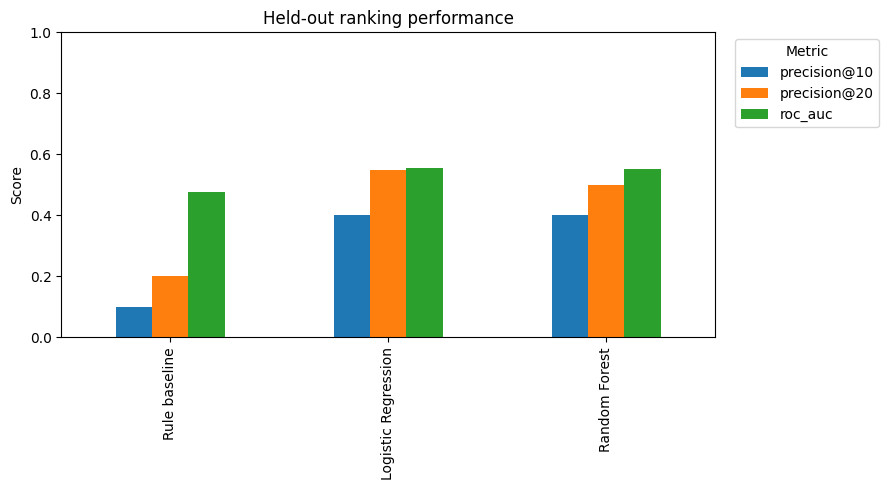

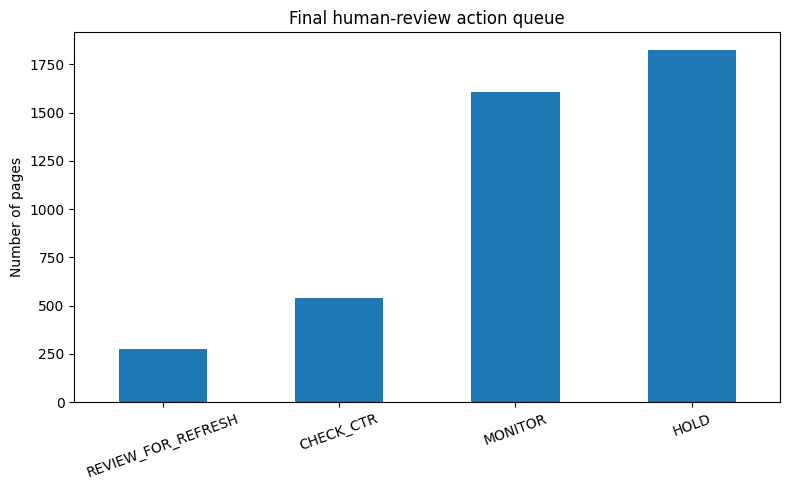

Saved: work/figures/capstone_model_vs_baseline.png
Saved: work/figures/capstone_action_distribution.png
Saved: work/outputs/capstone_metrics.json

Metrics receipt:
{
  "eligible_rows": 85967,
  "held_out_rows": 4247,
  "train_clients": 31,
  "test_clients": 8,
  "client_overlap": 0,
  "test_base_rate": 0.41959029903461265,
  "random_state": 42,
  "baseline_precision_at_10": 0.1,
  "baseline_precision_at_20": 0.2,
  "baseline_roc_auc": 0.47595290293059056,
  "logistic_precision_at_10": 0.4,
  "logistic_precision_at_20": 0.55,
  "logistic_roc_auc": 0.5537236234328864,
  "rf_precision_at_10": 0.4,
  "rf_precision_at_20": 0.5,
  "rf_roc_auc": 0.5529254683412899,
  "review_for_refresh": 276,
  "check_ctr": 538,
  "monitor": 1608,
  "hold": 1825
}


In [11]:
import os
import json
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

# --------------------------------------------------
# Figure 1: model vs baseline
# --------------------------------------------------

comparison_plot = (
    results
    .set_index("method")[
        ["precision@10", "precision@20", "roc_auc"]
    ]
)

ax = comparison_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("Held-out ranking performance")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

results_figure_path = (
    "work/figures/capstone_model_vs_baseline.png"
)

plt.savefig(
    results_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# --------------------------------------------------
# Figure 2: recommendation distribution
# --------------------------------------------------

action_counts = (
    ranked_recommendations["action"]
    .value_counts()
    .reindex(
        [
            "REVIEW_FOR_REFRESH",
            "CHECK_CTR",
            "MONITOR",
            "HOLD",
        ]
    )
)

ax = action_counts.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Final human-review action queue")
ax.set_ylabel("Number of pages")
ax.set_xlabel("")
ax.tick_params(
    axis="x",
    rotation=20,
)

plt.tight_layout()

actions_figure_path = (
    "work/figures/capstone_action_distribution.png"
)

plt.savefig(
    actions_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# --------------------------------------------------
# Metrics receipt
# --------------------------------------------------

capstone_metrics = {
    "eligible_rows": int(len(capstone_frame)),
    "held_out_rows": int(len(test_idx)),
    "train_clients": int(len(train_clients)),
    "test_clients": int(len(test_clients)),
    "client_overlap": int(
        len(train_clients & test_clients)
    ),
    "test_base_rate": float(test_base_rate),
    "random_state": RANDOM_STATE,

    "baseline_precision_at_10": float(
        results.loc[
            results["method"] == "Rule baseline",
            "precision@10",
        ].iloc[0]
    ),
    "baseline_precision_at_20": float(
        results.loc[
            results["method"] == "Rule baseline",
            "precision@20",
        ].iloc[0]
    ),
    "baseline_roc_auc": float(
        results.loc[
            results["method"] == "Rule baseline",
            "roc_auc",
        ].iloc[0]
    ),

    "logistic_precision_at_10": float(
        results.loc[
            results["method"] == "Logistic Regression",
            "precision@10",
        ].iloc[0]
    ),
    "logistic_precision_at_20": float(
        results.loc[
            results["method"] == "Logistic Regression",
            "precision@20",
        ].iloc[0]
    ),
    "logistic_roc_auc": float(
        results.loc[
            results["method"] == "Logistic Regression",
            "roc_auc",
        ].iloc[0]
    ),

    "rf_precision_at_10": float(
        results.loc[
            results["method"] == "Random Forest",
            "precision@10",
        ].iloc[0]
    ),
    "rf_precision_at_20": float(
        results.loc[
            results["method"] == "Random Forest",
            "precision@20",
        ].iloc[0]
    ),
    "rf_roc_auc": float(
        results.loc[
            results["method"] == "Random Forest",
            "roc_auc",
        ].iloc[0]
    ),

    "review_for_refresh": int(
        action_counts["REVIEW_FOR_REFRESH"]
    ),
    "check_ctr": int(
        action_counts["CHECK_CTR"]
    ),
    "monitor": int(
        action_counts["MONITOR"]
    ),
    "hold": int(
        action_counts["HOLD"]
    ),
}

metrics_path = (
    "work/outputs/capstone_metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(
        capstone_metrics,
        f,
        indent=2,
    )

print("Saved:", results_figure_path)
print("Saved:", actions_figure_path)
print("Saved:", metrics_path)

print("\nMetrics receipt:")
print(
    json.dumps(
        capstone_metrics,
        indent=2,
    )
)

## ML-12 — Demo and communication cuts

### 5-minute demo outline

**1. Problem — 45 seconds**

This project asks whether historical search-performance signals can help prioritize which published content pages deserve human review for possible refresh work. The goal is prioritization, not automatic content editing.

**2. Data — 45 seconds**

I used pseudonymized FlyRank production search-performance data. The final eligible population contained 85,967 pages across 39 clients. Historical features came from March 1–21, 2026, while March 22–31 was reserved for defining the later decline outcome.

**3. Method — 60 seconds**

I compared a transparent staleness-and-visibility baseline with Logistic Regression and Random Forest. All models used the same five pre-decision search features and were evaluated on the same grouped client holdout with zero client overlap.

**4. Results — 60 seconds**

The held-out set contained 4,247 pages with a positive base rate of 41.96%. The rule baseline achieved 10% precision@10 and 20% precision@20. Logistic Regression improved this to 40% and 55%, while Random Forest reached 40% and 50%. Overall ROC-AUC remained modest at about 0.55.

**5. Action playbook — 60 seconds**

The final queue assigns pages to four human-review actions: `REVIEW_FOR_REFRESH`, `CHECK_CTR`, `MONITOR`, and `HOLD`. The queue contains 276 refresh-review candidates, 538 CTR checks, 1,608 monitoring items, and 1,825 held items.

**6. Limitation and takeaway — 30 seconds**

The model does not prove that refreshing a page will improve performance. Its value is narrower: it provides a reproducible decision-support signal that can help editors decide where to investigate first.

### Social-post cut

I built a content refresh opportunity scoring workflow on the FlyRank ML Internship dataset, using grouped client validation to test whether historical search signals can improve page-review prioritization.

On a 4,247-page held-out set, Logistic Regression reached 55% precision@20 compared with 20% for the transparent rule baseline, although overall ROC-AUC remained modest at 0.5537.

The final output is a human-reviewed action queue rather than an automated content system: 276 pages were prioritized for refresh review, 538 for CTR checks, 1,608 for monitoring, and 1,825 for hold.

### Employer-facing summary

I built an end-to-end content refresh prioritization pipeline using pseudonymized production search-performance data from the FlyRank ML Internship dataset.

I designed leakage-safe features, grouped validation by client, compared a transparent baseline with Logistic Regression and Random Forest, and converted the validated ranking into a reproducible human-review action queue.

The best fresh result reached 55% precision@20 versus 20% for the rule baseline, while the modest ROC-AUC of 0.5537 kept the final recommendation appropriately framed as decision support rather than automation.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
